<a href="https://colab.research.google.com/github/Napa-MadhuSudhan/MS_DS_Journey/blob/main/projects/Alzheimers_Disease_%7C_96_Accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'alzheimers-disease-patient-data:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F5589285%2F9240070%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240903%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240903T021639Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D61256fa1f491c5234ce58b921411e570bf5b8b4f902dc5b8888630b01114fca0158f1143abf25220c3884be2163d441525745c739aa555bdb5d5fc2f3458157522105060292ec6e3fb665c0b2e34b471fcbc5418a70d35912027d55ceaa9d3cdcfc01ab1f8018ace898e8a8105e36fb69dc0e56ac3b509b209a1c5887d3869efe8aee2fa3e5fa8b9dfe3f3464b2f7599dcc3b971b24977463ebd2d54a8c5a522ade90ed98c7a9df99119cd2bf19c9ce345e64143ff3ddddb5804bc78b32ed9446d4d3e60131da00eb81ffc3de368d3f4923c7e8b244c782ebcc1e06db796f9d51bcbc2957cecae431dece926621314a8dca87f0ca7f9c5c3e11b3ac08d7dd85d'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 274411 bytes downloaded
Downloaded and uncompressed: alzheimers-disease-patient-data
Data source import complete.


In [3]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 5.2 MB/s eta 0:00:00


In [4]:
# importing all the Necessary Libarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [5]:
df = pd.read_csv('/kaggle/input/alzheimers-disease-patient-data/alzheimers_disease_patient_data.csv')

In [6]:
df.head()



,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [7]:
df.describe()



,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64


## We can drop PatientID and DoctorInCharge as these feature does not add any signficence to our model


In [9]:

df.drop(["PatientID","DoctorInCharge"],axis=1,inplace=True)



In [10]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [11]:
df.isnull().sum()


,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0



## Our Data is clean and it doesnot have any missing values . we can skip the step of handling the missing values.


# Handling Outliers

In [12]:
df[ 'FunctionalAssessment'][1]

7.118695504189474

In [13]:
plt.rcParams['figure.figsize'] = [12, 8]

<Axes: >

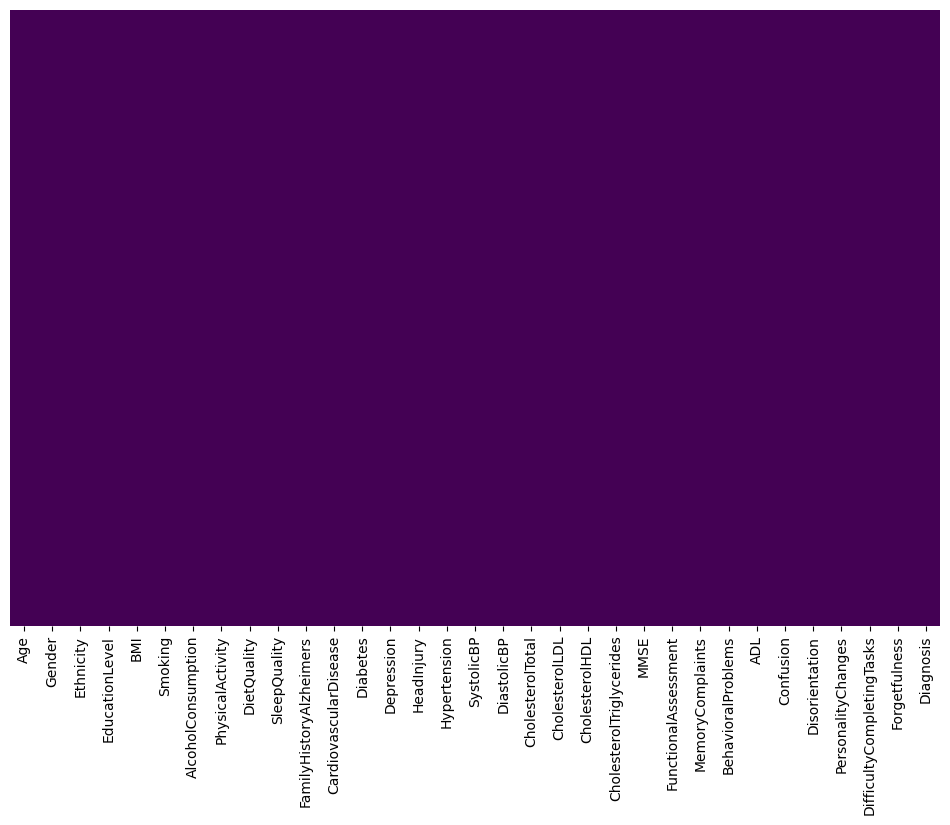

In [14]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

## From above Heat map  we can conclude that there is no outliers in the data


# Correlation Checking

In [15]:

# Compute the correlation matrix
corr_matrix = df.corr()

# Create a mask for correlations greater than 0.5 or less than -0.5
mask = (corr_matrix.abs() > 0.5) & (corr_matrix != 1.0)  # Exclude self-correlations

# Extract pairs of features with significant correlations
significant_corrs = corr_matrix[mask]

# Remove rows and columns where all values are NaN
significant_corrs = significant_corrs.dropna(how='all').dropna(axis=1, how='all')

print("Significant correlations (|correlation| > 0.5):")
print(significant_corrs)


Significant correlations (|correlation| > 0.5):
Empty DataFrame
Columns: []
Index: []


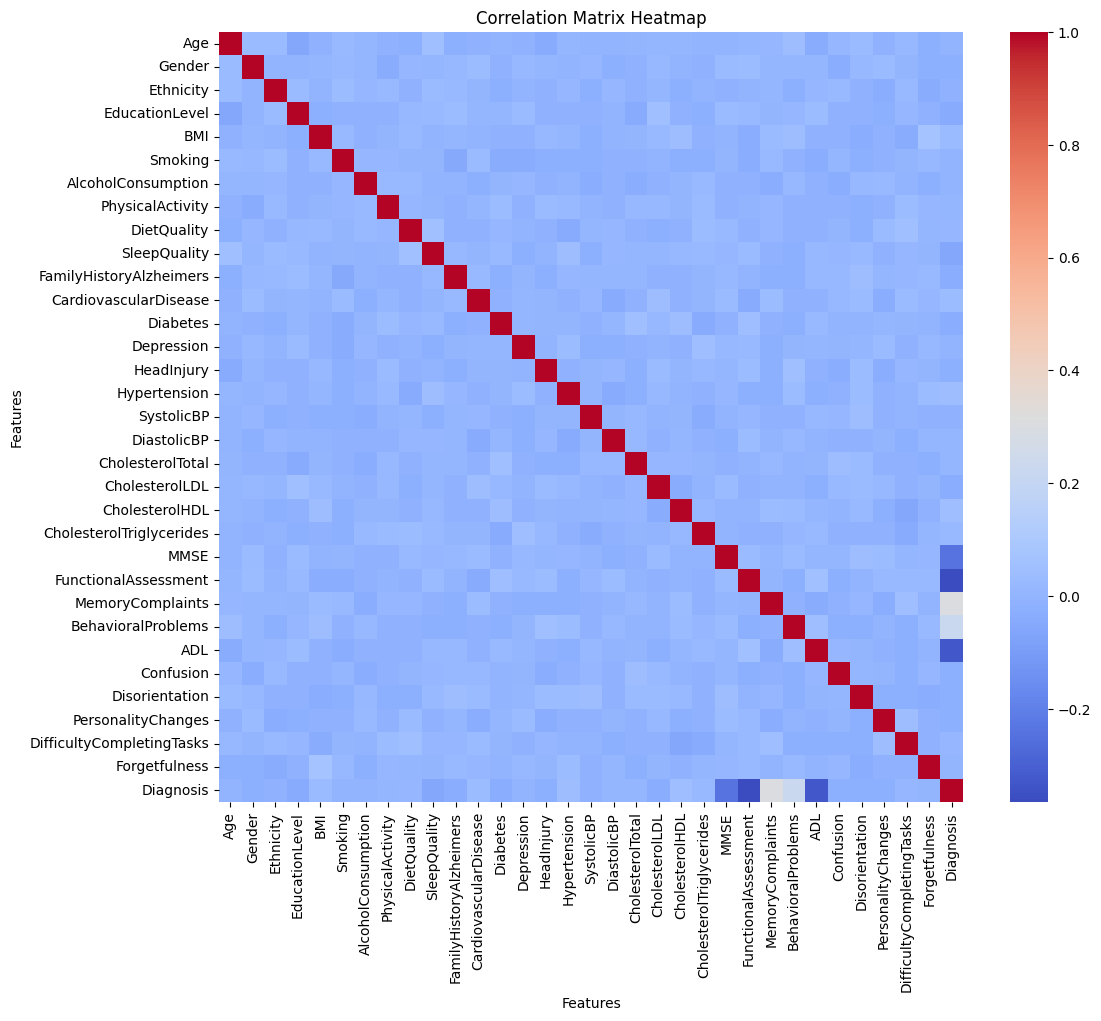

In [16]:

# Set up the matplotlib figure with increased size
plt.figure(figsize=(12, 10))  # Adjust the width and height as needed

# Create the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', cbar=True)

# Add titles and labels
plt.title('Correlation Matrix Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')

# Show the plot
plt.show()



### From the above correlations matrix we can conclude that there is correlations between features of data

# Normalization

### Lets check the range of the values to identify the columns / features to be Scaled


In [17]:
for column in df.columns:
    print(f"{column} range is [{min(df[column]),max(df[column])}]")



Age range is [(60, 90)]
Gender range is [(0, 1)]
Ethnicity range is [(0, 3)]
EducationLevel range is [(0, 3)]
BMI range is [(15.00885118163106, 39.99276746402374)]
Smoking range is [(0, 1)]
AlcoholConsumption range is [(0.0020030991362718, 19.98929335906197)]
PhysicalActivity range is [(0.003616016826019, 9.987429413422252)]
DietQuality range is [(0.00938472011623, 9.99834567881401)]
SleepQuality range is [(4.002628659826611, 9.99984031668144)]
FamilyHistoryAlzheimers range is [(0, 1)]
CardiovascularDisease range is [(0, 1)]
Diabetes range is [(0, 1)]
Depression range is [(0, 1)]
HeadInjury range is [(0, 1)]
Hypertension range is [(0, 1)]
SystolicBP range is [(90, 179)]
DiastolicBP range is [(60, 119)]
CholesterolTotal range is [(150.09331559406317, 299.99335247432657)]
CholesterolLDL range is [(50.23070655980742, 199.96566510142804)]
CholesterolHDL range is [(20.00343401498445, 99.98032407804152)]
CholesterolTriglycerides range is [(50.40719361978579, 399.9418615941332)]
MMSE range is

Here I want to Normalise these features.
- Age
- Ethnicity
- BMI
- AlcoholConsumption
- PhysicalActivity
- DietQuality
- SleepQuality
- SystolicBP
- DiastolicBP
- CholesterolTotal
- CholesterolLDL
- CholesterolHDL
- CholesterolTriglycerides
- MMSE
- FunctionalAssessment
- ADL

1. **Age, BMI, Systolic BP, Diastolic BP, Cholesterol Total, Cholesterol LDL, Cholesterol HDL, Cholesterol Triglycerides, Alcohol Consumption, Physical Activity, Diet Quality, Sleep Quality**

- Normalization Method: **Min-Max Scaling**
- Reason: These features are continuous variables with a defined range. Min-Max Scaling will rescale the data to a range [0, 1] while preserving the relationships between the data points.




In [18]:
scaler = MinMaxScaler()
df[['Age', 'BMI', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']] = scaler.fit_transform(df[['Age', 'BMI', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']])


2. **Ethnicity**
- Normalization Method: One-Hot Encoding
- Reason: Ethnicity is a categorical variable with discrete values. One-Hot Encoding will convert this categorical data into binary vectors, which are suitable for most machine learning algorithms.

In [19]:
df = pd.get_dummies(df, columns=['Ethnicity'], drop_first=True)

3. MMSE, Functional Assessment, ADL
- Normalization Method: Z-Score Normalization (Standardization)
- Reason: These features are continuous but may not have a well-defined minimum or maximum. Z-Score normalization standardizes the data to have a mean of 0 and a standard deviation of 1, which is especially useful when features may have outliers or when the data does not have a clear upper/lower bound.


In [20]:
standard_scaler = StandardScaler()
df[['MMSE', 'FunctionalAssessment', 'ADL']] = standard_scaler.fit_transform(df[['MMSE', 'FunctionalAssessment', 'ADL']])
df.head()

,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,Ethnicity_1,Ethnicity_2,Ethnicity_3
0,0.433333,0,2,0.316960,0,0.665183,0.633375,0.133931,0.837564,0,...,-1.104434,0,0,0,1,0,0,False,False,False
1,0.966667,0,0,0.473058,0,0.227170,0.762862,0.050995,0.525021,0,...,-0.810601,0,0,0,0,1,0,False,False,False
2,0.433333,0,1,0.111553,0,0.978276,0.785408,0.181896,0.945597,1,...,0.724491,0,1,0,1,0,0,False,False,True
3,0.466667,1,1,0.752163,1,0.610751,0.843804,0.743443,0.731994,0,...,0.508044,0,0,0,0,0,0,False,False,False
4,0.966667,0,0,0.228472,0,0.923204,0.631707,0.078698,0.265892,0,...,-1.684679,0,0,1,1,0,0,False,False,False


# Splitting the Data into Train , Test dataset

In [21]:
X = df.drop('Diagnosis',axis =1)
y = df['Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression

In [22]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(random_state=42)

# Fit the model on the training data
logreg.fit(X_train, y_train)

# Predict on the test data
y_pred = logreg.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred)
print(f'Classification Report:\n{class_report}')


Accuracy: 0.83
Confusion Matrix:
[[248  29]
 [ 44 109]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79      0.71      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430



# Decision Tree

In [23]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_dt

# Accuracy
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_dt)
print(f'Classification Report:\n{class_report}')

Accuracy: 0.90
Confusion Matrix:
[[256  21]
 [ 22 131]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       277
           1       0.86      0.86      0.86       153

    accuracy                           0.90       430
   macro avg       0.89      0.89      0.89       430
weighted avg       0.90      0.90      0.90       430



# Random Forest

In [24]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_rf)
print(f'Classification Report:\n{class_report}')

Accuracy: 0.92
Confusion Matrix:
[[272   5]
 [ 28 125]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.96      0.82      0.88       153

    accuracy                           0.92       430
   macro avg       0.93      0.90      0.91       430
weighted avg       0.93      0.92      0.92       430



# Gradient Boosting

In [25]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_gb)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_gb)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_gb)
print(f'Classification Report:\n{class_report}')

Accuracy: 0.96
Confusion Matrix:
[[271   6]
 [ 12 141]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       277
           1       0.96      0.92      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430
weighted avg       0.96      0.96      0.96       430



# Support Vector Machine (SVM)

In [26]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_svm)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_svm)
print(f'Classification Report:\n{class_report}')


Accuracy: 0.82
Confusion Matrix:
[[246  31]
 [ 45 108]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       277
           1       0.78      0.71      0.74       153

    accuracy                           0.82       430
   macro avg       0.81      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



# K-Nearest Neighbor (KNN)

In [27]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_knn)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_knn)
print(f'Classification Report:\n{class_report}')

Accuracy: 0.69
Confusion Matrix:
[[232  45]
 [ 87  66]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       277
           1       0.59      0.43      0.50       153

    accuracy                           0.69       430
   macro avg       0.66      0.63      0.64       430
weighted avg       0.68      0.69      0.68       430



# Naive Bayes

In [28]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_nb)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_nb)
print(f'Classification Report:\n{class_report}')


Accuracy: 0.83
Confusion Matrix:
[[245  32]
 [ 40 113]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       277
           1       0.78      0.74      0.76       153

    accuracy                           0.83       430
   macro avg       0.82      0.81      0.82       430
weighted avg       0.83      0.83      0.83       430



# XGBoost

In [29]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_xgb)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_xgb)
print(f'Classification Report:\n{class_report}')

Accuracy: 0.96
Confusion Matrix:
[[271   6]
 [ 13 140]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       277
           1       0.96      0.92      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430
weighted avg       0.96      0.96      0.96       430



# LightGBM

In [30]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lgb)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_lgb)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_lgb)
print(f'Classification Report:\n{class_report}')


[LightGBM] [Info] Number of positive: 607, number of negative: 1112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3303
[LightGBM] [Info] Number of data points in the train set: 1719, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.353112 -> initscore=-0.605387
[LightGBM] [Info] Start training from score -0.605387
Accuracy: 0.96
Confusion Matrix:
[[272   5]
 [ 13 140]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       277
           1       0.97      0.92      0.94       153

    accuracy                           0.96       430
   macro avg       0.96      0.95      0.95       430
weighted avg       0.96      0.96      0.96       430



# Catboost

In [31]:
catboost_model = CatBoostClassifier(random_state=42, verbose=0)
catboost_model.fit(X_train, y_train)
y_pred_catboost = catboost_model.predict(X_test)
cm_catboost = confusion_matrix(y_test, y_pred_catboost)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_catboost)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_catboost)
print(f'Confusion Matrix:\n{conf_matrix}')

# Classification Report
class_report = classification_report(y_test, y_pred_catboost)
print(f'Classification Report:\n{class_report}')


Accuracy: 0.95
Confusion Matrix:
[[271   6]
 [ 14 139]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       277
           1       0.96      0.91      0.93       153

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



#  Accuracy scores of all the Algorithms

<ipython-input-32-32cebf957511>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies_percentage.keys()), y=list(accuracies_percentage.values()), palette='viridis')


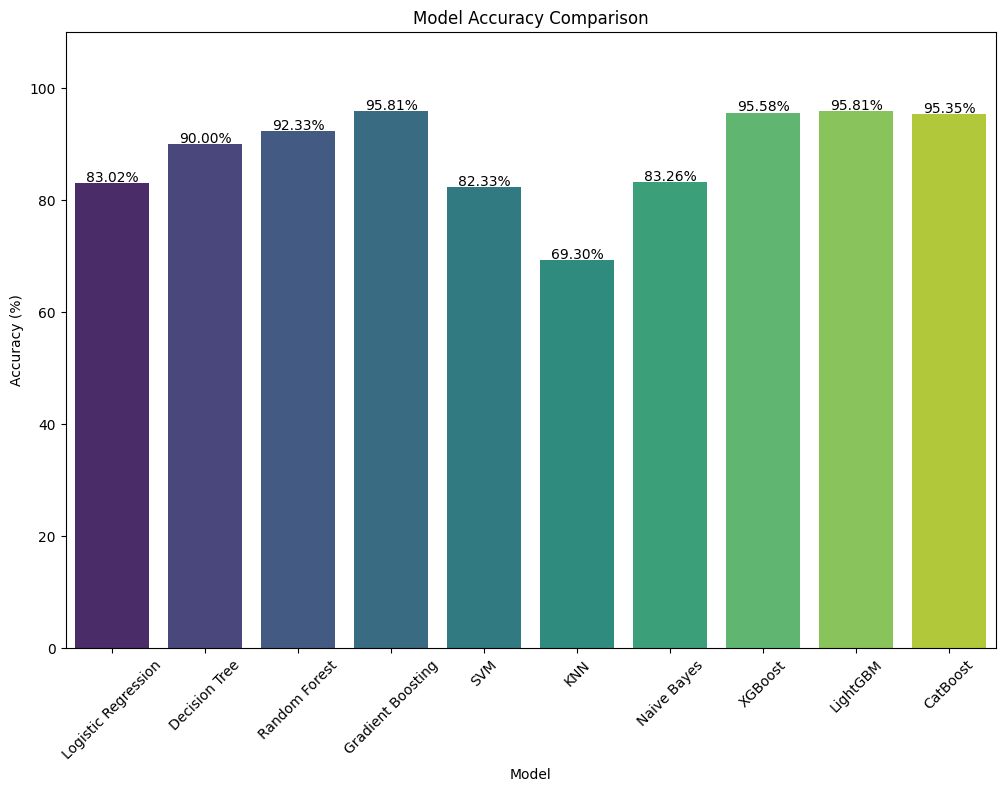

In [32]:
accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
    'LightGBM': accuracy_score(y_test, y_pred_lgb),
    'CatBoost': accuracy_score(y_test, y_pred_catboost)
}

# Convert accuracy to percentage
accuracies_percentage = {model: accuracy * 100 for model, accuracy in accuracies.items()}

# Plot accuracy scores
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=list(accuracies_percentage.keys()), y=list(accuracies_percentage.values()), palette='viridis')

# Add value labels on top of bars
for p in ax.patches:
    width = p.get_width()
    plt.text(p.get_x() + width / 2, p.get_height() + 1, f'{p.get_height():.2f}%',
             ha='center', va='center', fontsize=10, color='black')

plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 110)  # Adjust y-axis to ensure labels fit
plt.show()

